In [2]:
import folium

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
V_228 = pd.read_csv('../dataset/PeMSD7/V_228.csv')
V_1026 = pd.read_csv('../dataset/PeMSD7/V_1026.csv')
station_info_228 = pd.read_csv('../dataset/PeMSD7/PeMSD7_M_Station_Info.csv')

traffic_228_2d = V_228.values
traffic_1026_2d = V_1026.values

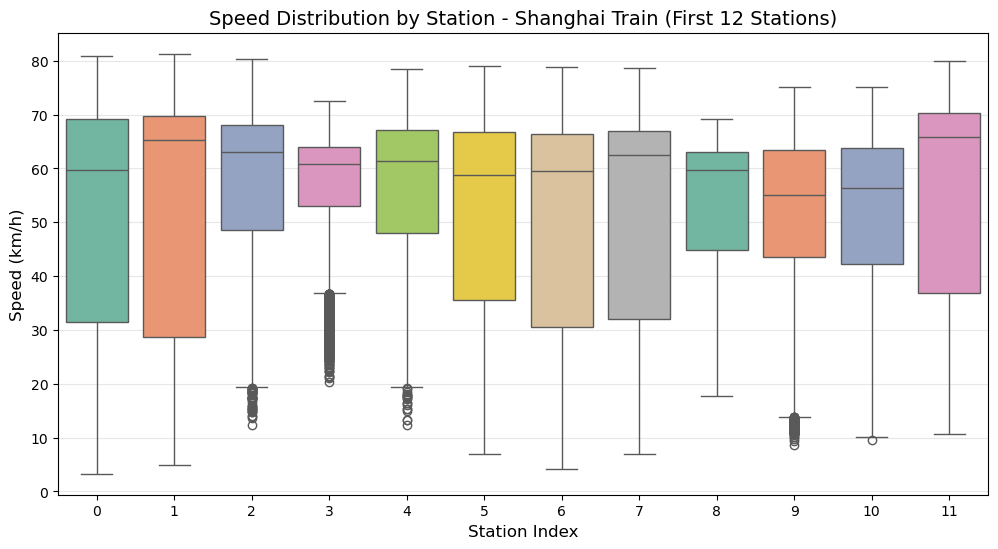

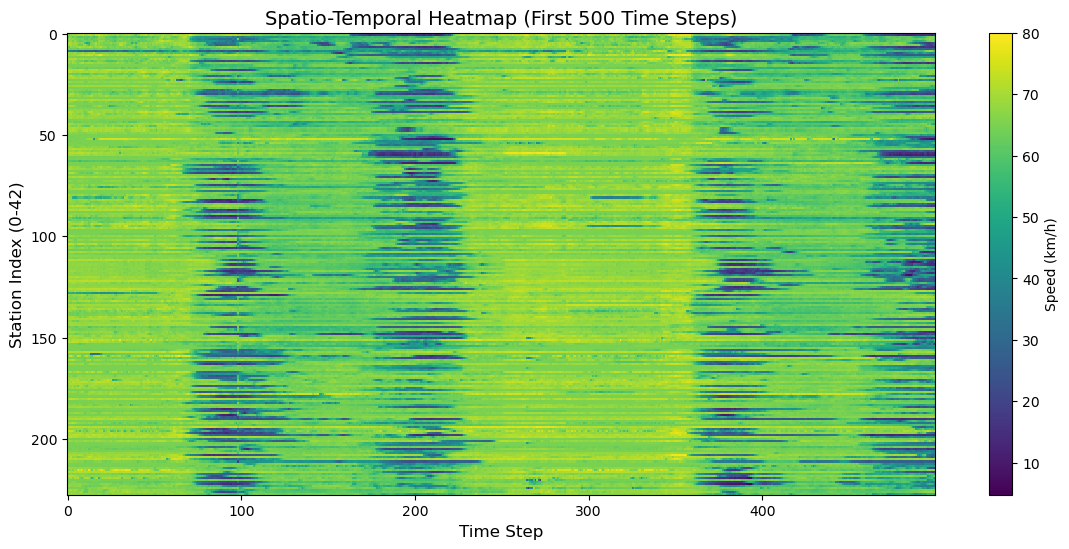

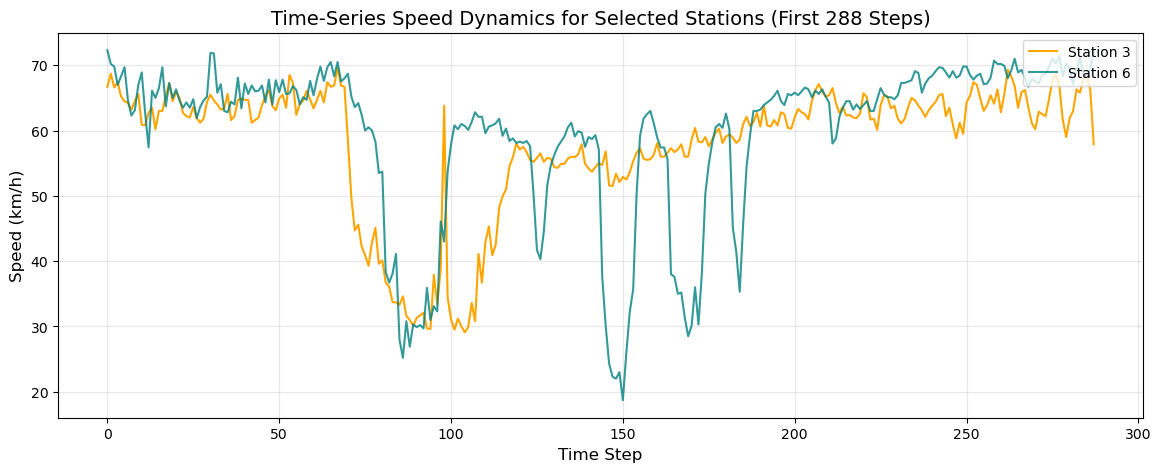

In [4]:
plt.figure(figsize=(12, 6))
data_to_plot = traffic_228_2d[:, :12] 

sns.boxplot(data=data_to_plot, palette="Set2")

plt.title('Speed Distribution by Station - Shanghai Train (First 12 Stations)', fontsize=14)
plt.xlabel('Station Index', fontsize=12)
plt.ylabel('Speed (km/h)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# plt.savefig('../Results/Plots/Shanghai/shanghai_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


plt.figure(figsize=(14, 6))

time_slice = 500
heatmap_data = traffic_228_2d[:time_slice, :].T 

plt.imshow(heatmap_data, aspect='auto', cmap='viridis', interpolation='nearest')

plt.colorbar(label='Speed (km/h)')
plt.title(f'Spatio-Temporal Heatmap (First {time_slice} Time Steps)', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Station Index (0-42)', fontsize=12)

# plt.savefig('../Results/Plots/Shanghai/shanghai_st_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(14, 5))

time_steps_to_show = 288 

plt.plot(traffic_228_2d[:time_steps_to_show, 3], label='Station 3', color='orange', linewidth=1.5)
plt.plot(traffic_228_2d[:time_steps_to_show, 6], label='Station 6', color='teal', linewidth=1.5, alpha=0.8)

plt.title(f'Time-Series Speed Dynamics for Selected Stations (First {time_steps_to_show} Steps)', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Speed (km/h)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# plt.savefig('../Results/Plots/Shanghai/shanghai_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Temporal EDA

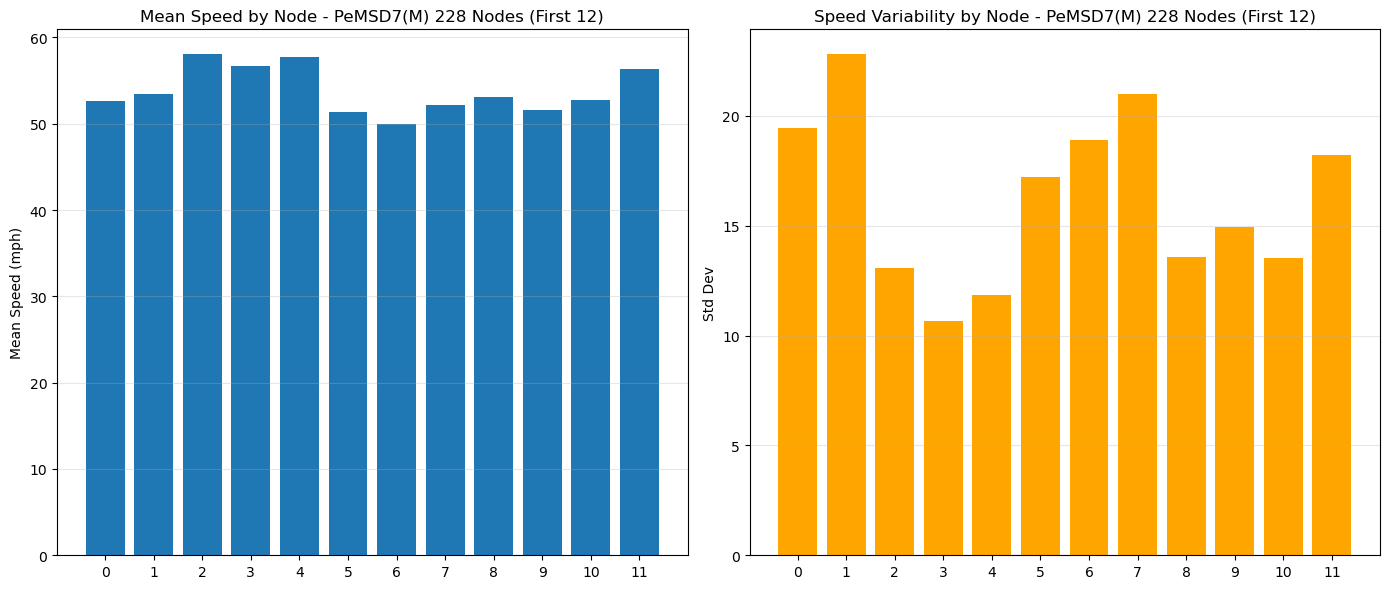

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean values by station
station_means_228 = traffic_228_2d.mean(axis=0)[:12]
axes[0].bar(range(len(station_means_228)), station_means_228)
axes[0].set_xticks(range(len(station_means_228)))
axes[0].set_xticklabels(range(len(station_means_228)), fontsize=10)
axes[0].set_ylabel('Mean Speed (mph)')
axes[0].set_title('Mean Speed by Node - PeMSD7(M) 228 Nodes (First 12)')
axes[0].grid(True, alpha=0.3, axis='y')

# Standard deviation by station
station_std_228 = traffic_228_2d.std(axis=0)[:12]
axes[1].bar(range(len(station_std_228)), station_std_228, color='orange')
axes[1].set_xticks(range(len(station_std_228)))
axes[1].set_xticklabels(range(len(station_std_228)), fontsize=10)
axes[1].set_ylabel('Std Dev')
axes[1].set_title('Speed Variability by Node - PeMSD7(M) 228 Nodes (First 12)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../Results/Plots/pemsd7_228_eda.png', dpi=150, bbox_inches='tight')
plt.show()

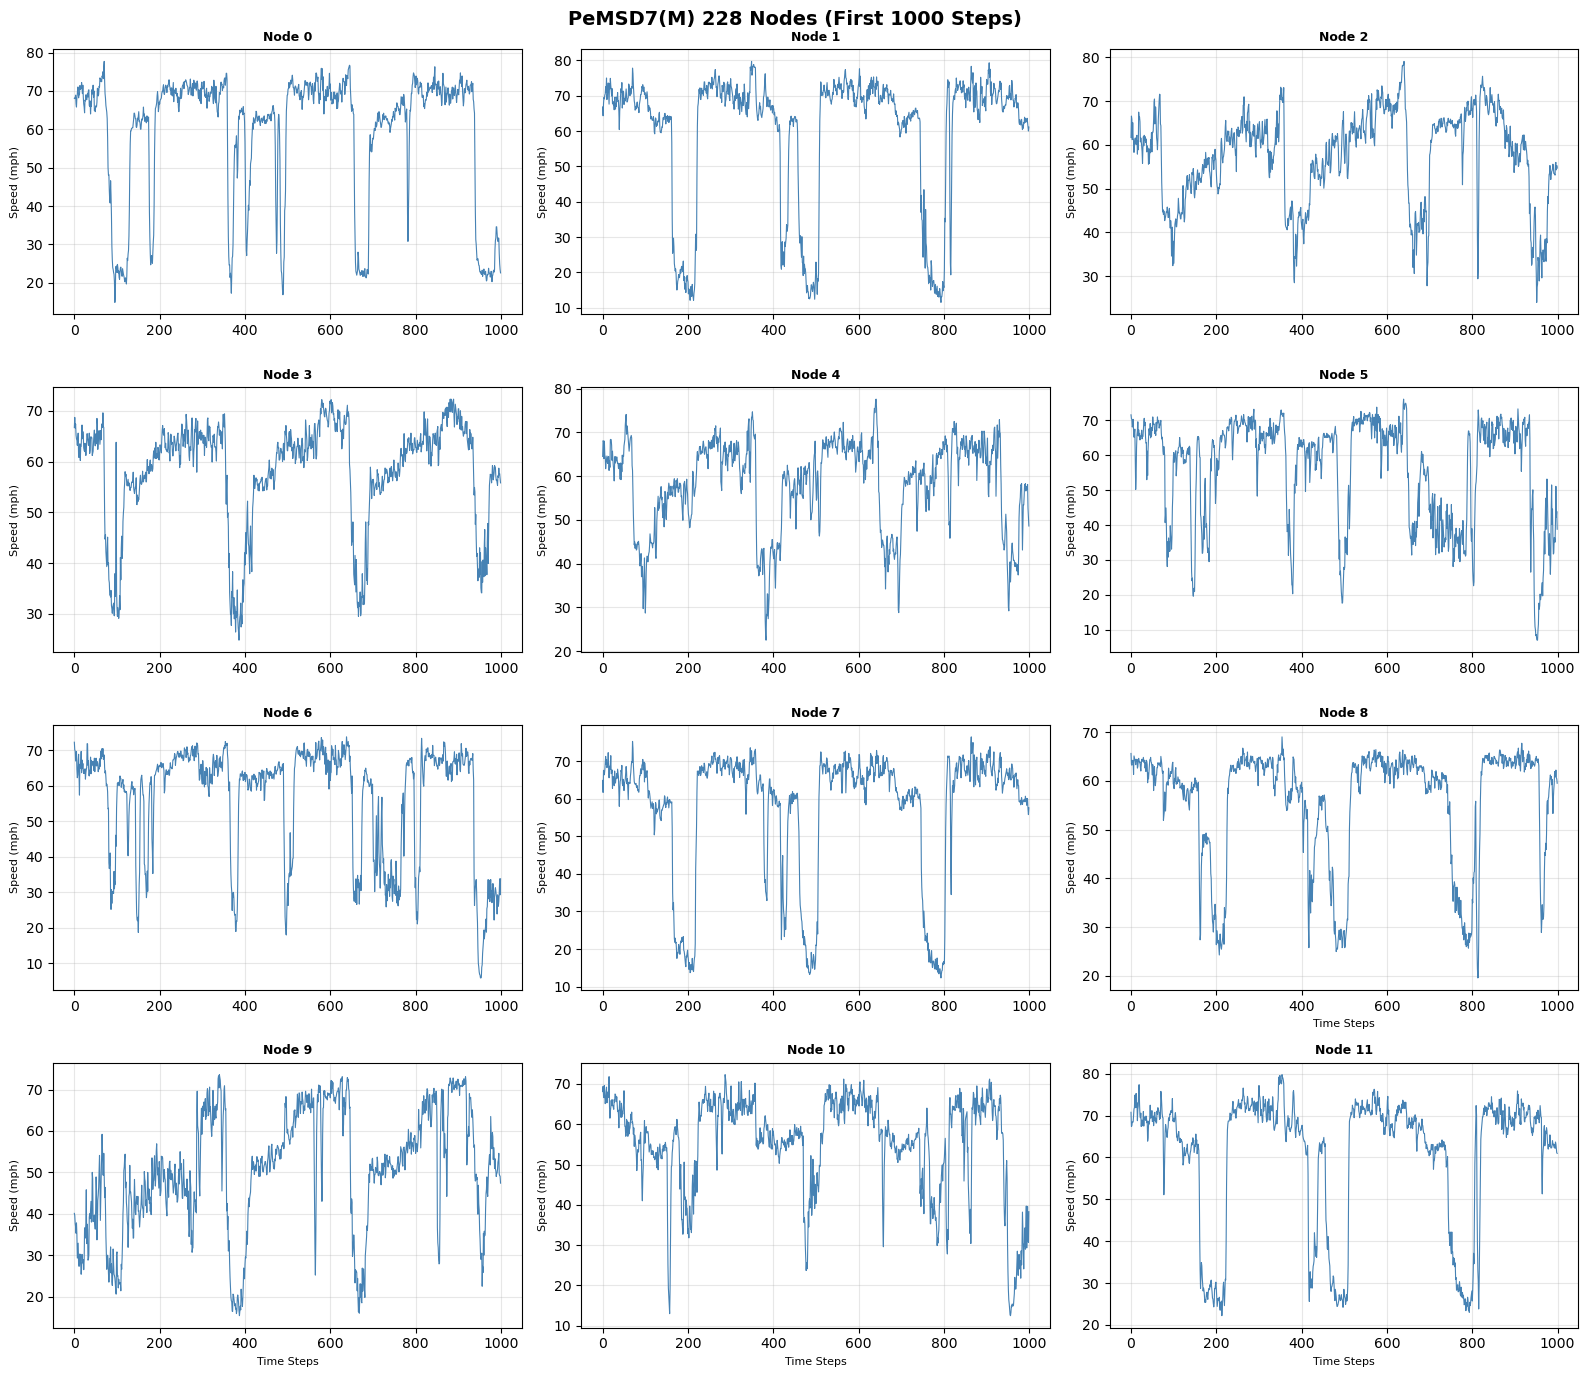

In [21]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i in range(min(12, traffic_228_2d.shape[1])):
    axes[i].plot(traffic_228_2d[:1000, i], linewidth=0.8, color='steelblue')
    axes[i].set_title(f'Node {i}', fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Speed (mph)', fontsize=8)
    axes[i].grid(True, alpha=0.3)
    if i >= 8:
        axes[i].set_xlabel('Time Steps', fontsize=8)

plt.suptitle('PeMSD7(M) 228 Nodes (First 1000 Steps)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Results/Plots/pemsd7_228_timeseries_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
stats_228 = pd.DataFrame({
    'Node': range(traffic_228_2d.shape[1]),
    'Mean': traffic_228_2d.mean(axis=0),
    'Std': traffic_228_2d.std(axis=0),
    'Min': traffic_228_2d.min(axis=0),
    'Max': traffic_228_2d.max(axis=0),
    'Median': np.median(traffic_228_2d, axis=0)
})

stats_228.to_csv('../Results/Performance/pemsd7_228_statistics.csv', index=False)

### Temporal EDA 1026

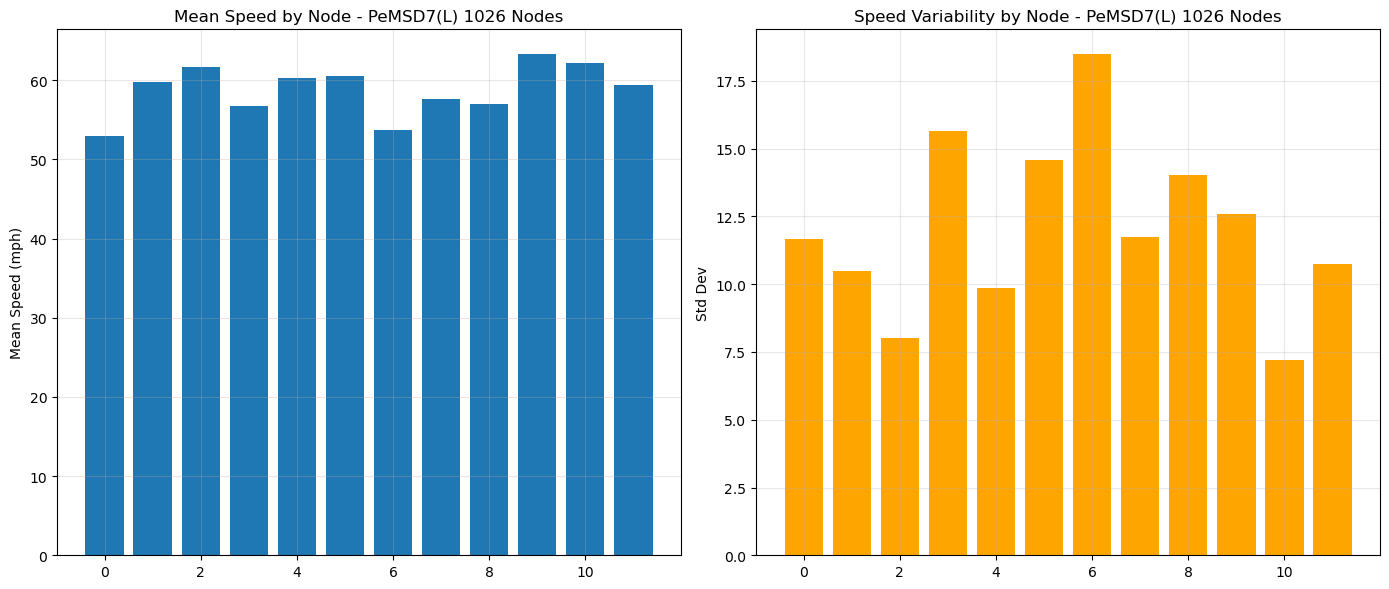

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

station_means_1026 = traffic_1026_2d.mean(axis=0)[:12]
axes[0].bar(range(len(station_means_1026)), station_means_1026)
axes[0].set_ylabel('Mean Speed (mph)')
axes[0].set_title('Mean Speed by Node - PeMSD7(L) 1026 Nodes')
axes[0].grid(True, alpha=0.3)

station_std_1026 = traffic_1026_2d.std(axis=0)[:12]
axes[1].bar(range(len(station_std_1026)), station_std_1026, color='orange')
axes[1].set_ylabel('Std Dev')
axes[1].set_title('Speed Variability by Node - PeMSD7(L) 1026 Nodes')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Results/Plots/pemsd7_1026_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
stats_1026 = pd.DataFrame({
    'Node': range(traffic_1026_2d.shape[1]),
    'Mean': traffic_1026_2d.mean(axis=0),
    'Std': traffic_1026_2d.std(axis=0),
    'Min': traffic_1026_2d.min(axis=0),
    'Max': traffic_1026_2d.max(axis=0),
    'Median': np.median(traffic_1026_2d, axis=0)
})
stats_1026.to_csv('../Results/Performance/pemsd7_1026_statistics.csv', index=False)

## PeMSD map
There's not enough information to narrow down the number of station, the original paper didn't mention how they choose the station, and also they didn't put the 1026 data into their repository.
`d07_text_meta_2012_05_02` data is from https://pems.dot.ca.gov/?dnode=Clearinghouse&type=meta&district_id=7&submit=Submit

In [46]:
station_info_1026 = pd.read_csv('../dataset/PeMSD7/d07_text_meta_2012_05_02.txt', sep='\t')
station_info_1026 = station_info_1026[station_info_1026['Type'] == 'ML']
station_info_1026.drop_duplicates(subset=['ID'])

,ID,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
0,715898,5,S,7,37,40032.0,.71,117.280,33.880183,-118.021787,0.430,ML,3,PHOEBE,2029,NaN,NaN,NaN
16,715915,5,N,7,37,52526.0,5.5,122.133,33.924353,-118.084803,0.475,ML,3,TINA,2026,NaN,NaN,NaN
17,715916,5,S,7,37,52526.0,5.5,122.070,33.924281,-118.084952,0.410,ML,4,TINA,2026,NaN,NaN,NaN
19,715918,5,N,7,37,52526.0,6.2,122.833,33.933110,-118.091005,0.615,ML,3,ORR - DAY,2579,NaN,NaN,NaN
21,715920,5,S,7,37,52526.0,6.64,123.210,33.938544,-118.094941,0.130,ML,4,S OF 605,2296,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4570,774245,90,W,7,37,44000.0,.93,0.009,33.984652,-118.442457,0.035,ML,2,E/O CULVER,2323,NaN,NaN,NaN
4579,774278,90,W,7,37,44000.0,2.42,2.466,33.988276,-118.403160,1.822,ML,3,W/O RTE 405,2928,NaN,NaN,NaN
4580,774279,90,E,7,37,44000.0,2.42,2.466,33.988048,-118.402906,1.822,ML,3,W/O RTE 405,2928,NaN,NaN,NaN
4584,774301,90,W,7,37,44000.0,1.61,0.689,33.982569,-118.430920,1.074,ML,3,CENTINELA,2261,NaN,NaN,NaN


In [44]:
la_center = [34.0522, -118.2437]
m = folium.Map(location=la_center, zoom_start=10, tiles='cartodbpositron')

station_info_1026_clean = station_info_1026.dropna(subset=['Latitude', 'Longitude'])
station_info_228_clean = station_info_228.dropna(subset=['Latitude', 'Longitude'])

la_center = [34.0522, -118.2437]
m = folium.Map(location=la_center, zoom_start=10, tiles='cartodbpositron')

for idx, row in station_info_1026_clean.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
    ).add_to(m)

for idx, row in station_info_228_clean.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
    ).add_to(m)

legend_html = '''
<div style="position: fixed; bottom: 50px; right: 50px; width: 180px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:12px; padding: 10px; border-radius: 5px;">
     
    <p style="margin: 0 0 5px 0; font-weight: bold;">Map Layers</p>
    
    <i style="border: 2px solid #003366; background: #0072B2; width: 12px; height: 12px; float: left; margin-right: 8px; border-radius: 50%;"></i>
    <span>PeMSD7-M (228 Nodes)</span><br style="clear: both; margin-bottom: 5px;">
    
    <i style="border: 1px solid gray; background: #999999; width: 8px; height: 8px; float: left; margin-right: 12px; border-radius: 50%; opacity: 0.5;"></i>
    <span>Base Network (1807 Nodes)</span>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m.save('../Results/Plots/pemsd7_layered_map.html')